# 02 · Data Cleaning & Validation
Every fix is logged: **what** was wrong, **why**, **how detected**, **how fixed** and **rows affected**. Unrepairable rows are quarantined, not silently deleted.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
MART = "data/processed/mart/"


In [2]:
from python.ingestion.load_raw import load_raw
from python.cleaning.cleaner import clean_all
from python.validation import quality_checks as q
raw = load_raw()
clean, issues = clean_all(raw)

In [3]:
issues[issues.rows_affected > 0][['table','issue','how_fixed','rows_affected']]

,table,issue,how_fixed,rows_affected
0,regions,Extra whitespace in city,TRIM + collapse inner spaces,4
1,regions,Inconsistent region (zone) labels,Lower/trim then map to canonical zone,8
2,products,Exact duplicate rows,Dropped duplicates,5
3,products,Inconsistent category names,Case/space-insensitive mapping table,78
4,products,"Price stored as text ('₹1,299.00')","Removed currency symbol & separators, cast to float",26
5,products,Missing unit_cost,Imputed = price x median cost ratio of same sub-category; flagged cost_imputed=True,15
6,products,Missing brand,Set to 'Unbranded',10
7,customers,Exact duplicate rows,Dropped,120
8,customers,Whitespace / inconsistent case in names & email,"TRIM, Title-case names, lower-case email",1153
9,customers,Inconsistent gender codes (M/F/male),Mapped to Male/Female; missing -> 'Not Specified',611


## Validation: re-run the same checks on the clean layer

In [4]:
r_raw, r_clean = q.run_checks(raw, 'raw'), q.run_checks(clean, 'clean')
scores = pd.concat([q.quality_score(r_raw), q.quality_score(r_clean)])
piv = scores.pivot_table(index='table', columns='layer', values='dq_score')[['raw','clean']]
piv['improvement'] = piv['clean'] - piv['raw']
piv.round(2)

layer,raw,clean,improvement
table,,,
customers,98.70,99.80,1.10
order_items,99.82,100.00,0.18
orders,95.26,99.95,4.69
payments,98.81,99.88,1.07
products,97.80,99.97,2.17
regions,94.44,100.00,5.56
returns,99.34,99.75,0.41
support_tickets,99.36,99.80,0.44


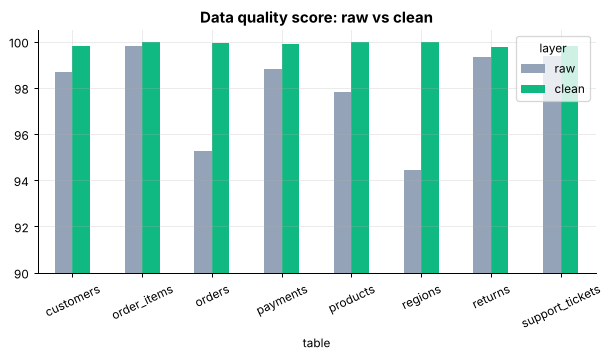

In [5]:
ax = piv[['raw','clean']].plot.bar(figsize=(8,3.5), color=['#94A3B8','#10B981'], title='Data quality score: raw vs clean')
ax.set_ylim(90, 100.5); plt.xticks(rotation=25); plt.show()

## Remaining exceptions (accepted by design)
Explicit *Unknown* members and nulls where the true value cannot be known. See `docs/data_quality.md`.

In [6]:
r_clean[(r_clean.failed_rows > 0) & ~r_clean.check.str.contains('info')][['table','check','column','failed_rows','pass_rate']]

,table,check,column,failed_rows,pass_rate
10,customers,not_null,email,361,96.99
11,customers,not_null,region_id,1,99.99
12,customers,not_null,signup_date,21,99.83
20,customers,allowed_values,gender,181,98.49
28,products,not_null,unit_price,1,99.81
29,products,not_null,unit_cost,1,99.81
36,products,allowed_values,category,1,99.81
47,orders,allowed_values,channel,394,99.30
79,payments,allowed_values,payment_method,336,99.40
83,returns,not_null,return_date,88,99.00


In [7]:
print('Row counts raw -> clean')
for t in raw: print(f'{t:16s} {len(raw[t]):>7,} -> {len(clean[t]):>7,}')

Row counts raw -> clean
regions               24 ->      24
customers         12,409 ->  12,001
products             525 ->     521
orders            56,336 ->  56,000
order_items      110,047 -> 109,498
payments          56,224 ->  56,000
returns            8,919 ->   8,823
support_tickets    6,725 ->   6,692
